### Brazilian E-Commerce Business Analysis
Notebook 1 - Data Profiling & Cleaning

Objective
This notebook performs data loading, data profiling, data quality assessment, data cleaning, and dataset preparation before exploratory data analysis.

#### Import Library

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

plt.style.use("ggplot")

#### Load Dataset

In [3]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
translation = pd.read_csv("../data/raw/product_category_name_translation.csv")
geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")

#### Datasets Overview

In [4]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Translation": translation,
    "Geolocation": geolocation
}

In [5]:
for name, df in datasets.items():
    print(f"{name}")
    print("-" * 20)
    print(f"Rows    : {df.shape[0]:,}")
    print(f"Columns : {df.shape[1]}")
    print()

Customers
--------------------
Rows    : 99,441
Columns : 5

Orders
--------------------
Rows    : 99,441
Columns : 8

Order Items
--------------------
Rows    : 112,650
Columns : 7

Payments
--------------------
Rows    : 103,886
Columns : 5

Reviews
--------------------
Rows    : 99,224
Columns : 7

Products
--------------------
Rows    : 32,951
Columns : 9

Sellers
--------------------
Rows    : 3,095
Columns : 4

Translation
--------------------
Rows    : 71
Columns : 2

Geolocation
--------------------
Rows    : 1,000,163
Columns : 5



#### First Five Rows

In [6]:
for name, df in datasets.items():
    print(name)
    display(df.head())

Customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Order Items


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Translation


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Geolocation


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


#### Dataset Information

In [7]:
for name, df in datasets.items():
    print(name)
    print("-" * 15)
    df.info()
    print("\n")

Customers
---------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


Orders
---------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order

#### Statistical Summary

In [8]:
for name, df in datasets.items():
    print(name)
    display(df.describe(include="all").T)

Customers


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,99441,99441,06b8999e2fba1a1fbc88172c00ba8bc7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,99441.0,NaN,NaN,NaN,35137.474583,29797.938996,1003.0,11347.0,24416.0,58900.0,99990.0
customer_city,99441,4119,sao paulo,15540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,99441,27,SP,41746,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Orders


,count,unique,top,freq
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1
customer_id,99441,99441,9ef432eb6251297304e76186b10a928d,1
order_status,99441,8,delivered,96478
order_purchase_timestamp,99441,98875,2018-08-02 12:05:26,3
order_approved_at,99281,90733,2018-02-27 04:31:10,9
order_delivered_carrier_date,97658,81018,2018-05-09 15:48:00,47
order_delivered_customer_date,96476,95664,2018-05-08 19:36:48,3
order_estimated_delivery_date,99441,459,2017-12-20 00:00:00,522


Order Items


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
seller_id,3095,3095,3442f8959a84dea7ee197c632cb2df15,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_zip_code_prefix,3095.0,NaN,NaN,NaN,32291.059451,32713.45383,1001.0,7093.5,14940.0,64552.5,99730.0
seller_city,3095,611,sao paulo,694,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_state,3095,23,SP,1849,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Translation


,count,unique,top,freq
product_category_name,71,71,beleza_saude,1
product_category_name_english,71,71,health_beauty,1


Geolocation


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,1000163.0,NaN,NaN,NaN,36574.166466,30549.33571,1001.0,11075.0,26530.0,63504.0,99990.0
geolocation_lat,1000163.0,NaN,NaN,NaN,-21.176153,5.715866,-36.605374,-23.603546,-22.919377,-19.97962,45.065933
geolocation_lng,1000163.0,NaN,NaN,NaN,-46.390541,4.269748,-101.466766,-48.573172,-46.637879,-43.767709,121.105394
geolocation_city,1000163,8011,sao paulo,135800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geolocation_state,1000163,27,SP,404268,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Missing Values

In [9]:
missing_summary = pd.DataFrame()

for name, df in datasets.items():

    missing = df.isnull().sum()
    percent = round(df.isnull().mean()*100,2)

    temp = pd.DataFrame({
        "Column": missing.index,
        "Missing": missing.values,
        "Percentage (%)": percent.values
    })

    temp["Dataset"] = name

    missing_summary = pd.concat([missing_summary,temp],ignore_index=True)

In [10]:
missing_summary = missing_summary[
    missing_summary["Missing"] > 0
].sort_values(
    by="Missing",
    ascending=False
)

missing_summary

,Column,Missing,Percentage (%),Dataset
28,review_comment_title,87656,88.34,Reviews
29,review_comment_message,58247,58.70,Reviews
11,order_delivered_customer_date,2965,2.98,Orders
10,order_delivered_carrier_date,1783,1.79,Orders
33,product_category_name,610,1.85,Products
35,product_description_lenght,610,1.85,Products
34,product_name_lenght,610,1.85,Products
36,product_photos_qty,610,1.85,Products
9,order_approved_at,160,0.16,Orders
37,product_weight_g,2,0.01,Products


#### Duplicate Values

In [11]:
duplicate_summary = []

for name, df in datasets.items():

    duplicate_summary.append({
        "Dataset":name,
        "Duplicate Rows":df.duplicated().sum()
    })

duplicate_summary = pd.DataFrame(duplicate_summary)

duplicate_summary

,Dataset,Duplicate Rows
0,Customers,0
1,Orders,0
2,Order Items,0
3,Payments,0
4,Reviews,0
5,Products,0
6,Sellers,0
7,Translation,0
8,Geolocation,261831


#### Data Types

In [12]:
datatype_summary = []

for name, df in datasets.items():

    datatype_summary.append({
        "Dataset":name,
        "Object":(df.dtypes=="object").sum(),
        "Numeric":(df.dtypes!="object").sum()
    })

datatype_summary = pd.DataFrame(datatype_summary)

datatype_summary

,Dataset,Object,Numeric
0,Customers,4,1
1,Orders,8,0
2,Order Items,4,3
3,Payments,2,3
4,Reviews,6,1
5,Products,2,7
6,Sellers,3,1
7,Translation,2,0
8,Geolocation,2,3


#### Unique Values Analysis
This section examines the uniqueness of key columns to better understand the data distribution and identify potential anomalies.

#### Number of unique values in each dataset

In [13]:
for name, df in datasets.items():
    print(name)

    unique_count = pd.DataFrame({
        "Column": df.columns,
        "Unique Values": [df[col].nunique() for col in df.columns]
    })

    display(unique_count)

Customers


,Column,Unique Values
0,customer_id,99441
1,customer_unique_id,96096
2,customer_zip_code_prefix,14994
3,customer_city,4119
4,customer_state,27


Orders


,Column,Unique Values
0,order_id,99441
1,customer_id,99441
2,order_status,8
3,order_purchase_timestamp,98875
4,order_approved_at,90733
5,order_delivered_carrier_date,81018
6,order_delivered_customer_date,95664
7,order_estimated_delivery_date,459


Order Items


...

,Column,Unique Values
0,seller_id,3095
1,seller_zip_code_prefix,2246
2,seller_city,611
3,seller_state,23


Translation


,Column,Unique Values
0,product_category_name,71
1,product_category_name_english,71


Geolocation


,Column,Unique Values
0,geolocation_zip_code_prefix,19015
1,geolocation_lat,717360
2,geolocation_lng,717613
3,geolocation_city,8011
4,geolocation_state,27


#### Order Status Distribution

In [14]:
order_status = (
    orders["order_status"]
    .value_counts()
    .reset_index()
)

order_status.columns = ["Order Status", "Count"]
order_status

,Order Status,Count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


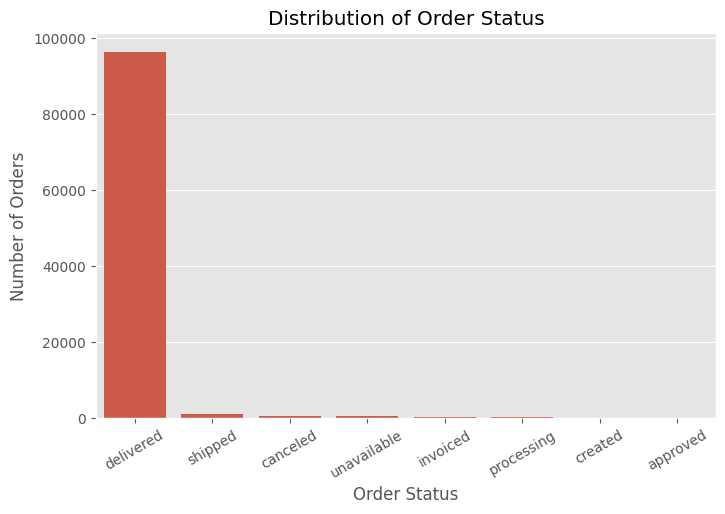

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=orders,
    x="order_status",
    order=orders["order_status"].value_counts().index
)
plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.show()

#### Payment Method Distribution

In [16]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

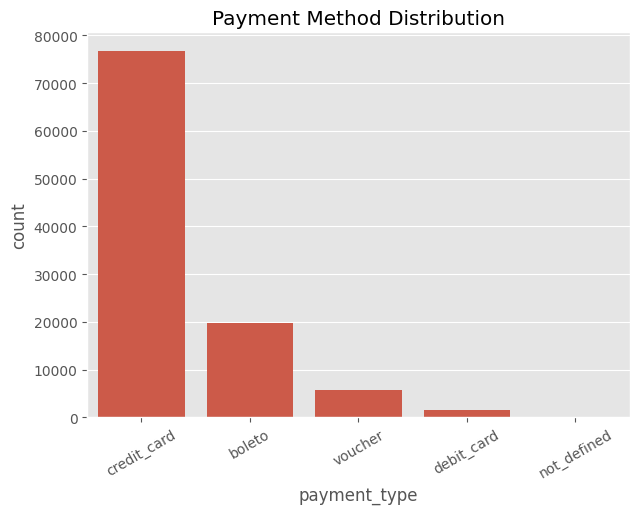

In [17]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=payments,
    x="payment_type",
    order=payments["payment_type"].value_counts().index
)
plt.title("Payment Method Distribution")
plt.xticks(rotation=30)
plt.show()

#### Review Score Distribution

In [18]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

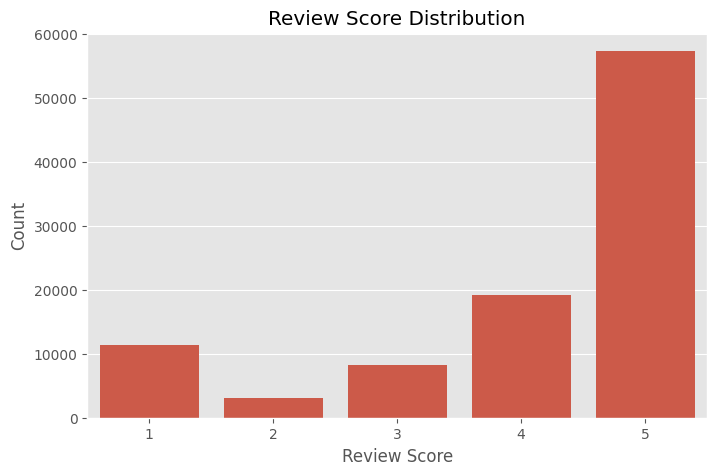

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=reviews,
    x="review_score"
)
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

#### Numerical Features Summary

In [20]:
numerical_columns = {
    "Order Items": order_items,
    "Payments": payments,
    "Products": products
}

for name, df in numerical_columns.items():
    print(name)
    display(df.describe().T)

Order Items


,count,mean,std,min,25%,50%,75%,max
order_item_id,112650.0,1.197834,0.705124,1.00,1.00,1.00,1.00,21.00
price,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.90,6735.00
freight_value,112650.0,19.990320,15.806405,0.00,13.08,16.26,21.15,409.68


Payments


,count,mean,std,min,25%,50%,75%,max
payment_sequential,103886.0,1.092679,0.706584,1.0,1.00,1.0,1.0000,29.00
payment_installments,103886.0,2.853349,2.687051,0.0,1.00,1.0,4.0000,24.00
payment_value,103886.0,154.100380,217.494064,0.0,56.79,100.0,171.8375,13664.08


Products


,count,mean,std,min,25%,50%,75%,max
product_name_lenght,32341.0,48.476949,10.245741,5.0,42.0,51.0,57.0,76.0
product_description_lenght,32341.0,771.495285,635.115225,4.0,339.0,595.0,972.0,3992.0
product_photos_qty,32341.0,2.188986,1.736766,1.0,1.0,1.0,3.0,20.0
product_weight_g,32949.0,2276.472488,4282.038731,0.0,300.0,700.0,1900.0,40425.0
product_length_cm,32949.0,30.815078,16.914458,7.0,18.0,25.0,38.0,105.0
product_height_cm,32949.0,16.937661,13.637554,2.0,8.0,13.0,21.0,105.0
product_width_cm,32949.0,23.196728,12.079047,6.0,15.0,20.0,30.0,118.0


#### Outliers Detection (Boxplot)

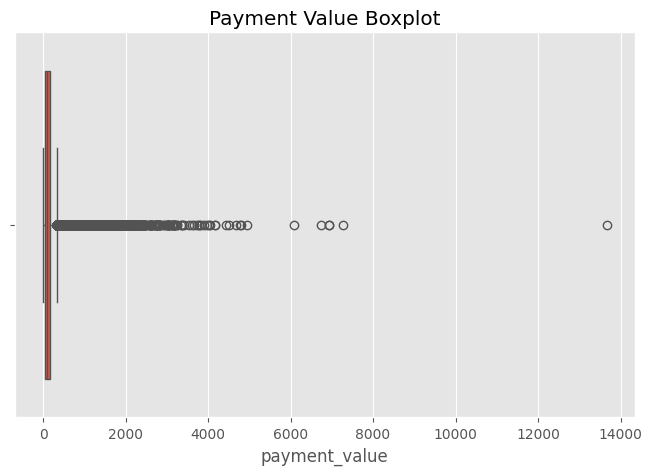

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=payments["payment_value"]
)
plt.title("Payment Value Boxplot")
plt.show()

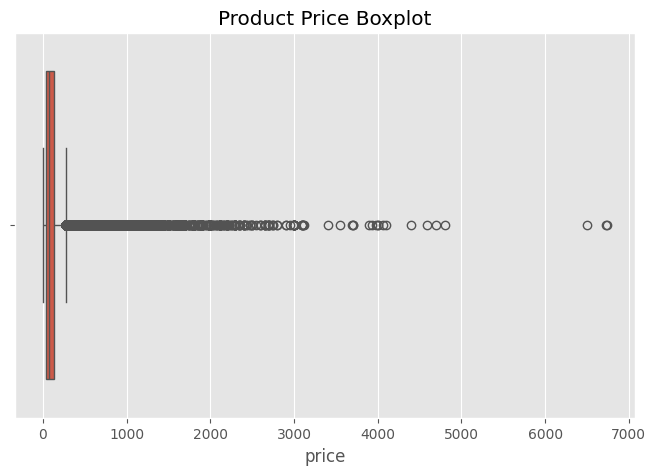

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=order_items["price"]
)
plt.title("Product Price Boxplot")
plt.show()

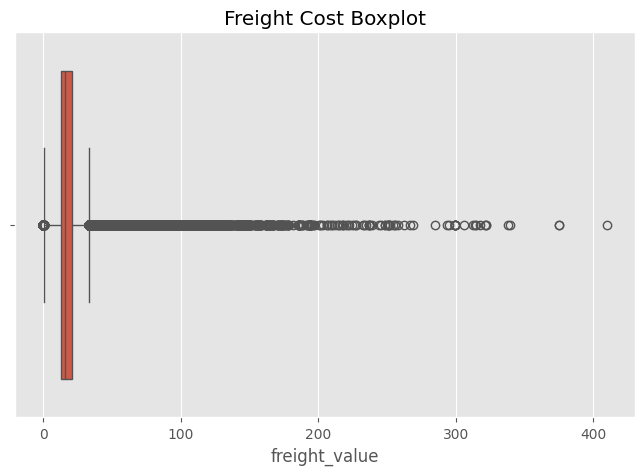

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=order_items["freight_value"]
)
plt.title("Freight Cost Boxplot")
plt.show()

#### Data Quality Assessment

In [24]:
quality_report = pd.DataFrame({
    "Dataset":[
        "Customers",
        "Orders",
        "Order Items",
        "Payments",
        "Reviews",
        "Products",
        "Sellers",
        "Translation",
        "Geolocation"
    ],
    "Status":[
        "Checked",
        "Checked",
        "Checked",
        "Checked",
        "Checked",
        "Checked",
        "Checked",
        "Checked",
        "Checked"
    ]
})

quality_report

,Dataset,Status
0,Customers,Checked
1,Orders,Checked
2,Order Items,Checked
3,Payments,Checked
4,Reviews,Checked
5,Products,Checked
6,Sellers,Checked
7,Translation,Checked
8,Geolocation,Checked


#### Initial Findings

From the profiling process, several observations were identified:

- Some datasets contain missing values.
- Timestamp columns are still stored as object datatype.
- Product category contains missing values.
- Review comments contain missing values.
- Payment values and product prices show several high-value outliers.
- No major duplicate records were found in the primary datasets.

These issues will be addressed in the data cleaning stage.

#### Data Cleaning

This section performs data cleaning by fixing data types, handling missing values, checking duplicates, and preparing each dataset before merging.

In [25]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

#### Missing Value Summary Before Cleaning

In [26]:
missing_before = pd.DataFrame()

for name, df in datasets.items():
    temp = pd.DataFrame({
        "Column": df.columns,
        "Missing": df.isnull().sum().values
    })

    temp["Dataset"] = name

    missing_before = pd.concat(
        [missing_before, temp],
        ignore_index=True
    )

missing_before[missing_before["Missing"] > 0]

,Column,Missing,Dataset
9,order_approved_at,160,Orders
10,order_delivered_carrier_date,1783,Orders
11,order_delivered_customer_date,2965,Orders
28,review_comment_title,87656,Reviews
29,review_comment_message,58247,Reviews
33,product_category_name,610,Products
34,product_name_lenght,610,Products
35,product_description_lenght,610,Products
36,product_photos_qty,610,Products
37,product_weight_g,2,Products


#### Handle Missing Values

In [27]:
products["product_category_name"] = products[
    "product_category_name"
].fillna("Unknown")

In [28]:
reviews["review_comment_title"] = reviews[
    "review_comment_title"
].fillna("No Title")

reviews["review_comment_message"] = reviews[
    "review_comment_message"
].fillna("No Review")

In [29]:
products[
    "product_name_lenght"
] = products["product_name_lenght"].fillna(
    products["product_name_lenght"].median()
)

products[
    "product_description_lenght"
] = products["product_description_lenght"].fillna(
    products["product_description_lenght"].median()
)

products[
    "product_photos_qty"
] = products["product_photos_qty"].fillna(
    products["product_photos_qty"].median()
)

products[
    "product_weight_g"
] = products["product_weight_g"].fillna(
    products["product_weight_g"].median()
)

products[
    "product_length_cm"
] = products["product_length_cm"].fillna(
    products["product_length_cm"].median()
)

products[
    "product_height_cm"
] = products["product_height_cm"].fillna(
    products["product_height_cm"].median()
)

products[
    "product_width_cm"
] = products["product_width_cm"].fillna(
    products["product_width_cm"].median()
)

#### Duplicate Check

In [30]:
for name, df in datasets.items():
    before = len(df)
    df.drop_duplicates(inplace=True)
    after = len(df)

    print(f"{name}: {before-after} duplicate rows removed")

Customers: 0 duplicate rows removed
Orders: 0 duplicate rows removed
Order Items: 0 duplicate rows removed
Payments: 0 duplicate rows removed
Reviews: 0 duplicate rows removed
Products: 0 duplicate rows removed
Sellers: 0 duplicate rows removed
Translation: 0 duplicate rows removed
Geolocation: 261831 duplicate rows removed


#### Missing Value Summary After Cleaning

In [31]:
missing_after = pd.DataFrame()

for name, df in datasets.items():
    temp = pd.DataFrame({
        "Column": df.columns,
        "Missing": df.isnull().sum().values
    })

    temp["Dataset"] = name

    missing_after = pd.concat(
        [missing_after, temp],
        ignore_index=True
    )

missing_after[missing_after["Missing"] > 0]

,Column,Missing,Dataset
9,order_approved_at,160,Orders
10,order_delivered_carrier_date,1783,Orders
11,order_delivered_customer_date,2965,Orders


#### Merge Dataset
Create a master analytical dataset.

In [32]:
master_df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [33]:
master_df = master_df.merge(
    order_items,
    on="order_id",
    how="left"
)

In [34]:
master_df = master_df.merge(
    payments,
    on="order_id",
    how="left"
)

In [35]:
master_df = master_df.merge(
    reviews,
    on="order_id",
    how="left"
)

In [36]:
master_df = master_df.merge(
    products,
    on="product_id",
    how="left"
)

In [37]:
master_df = master_df.merge(
    sellers,
    on="seller_id",
    how="left"
)

In [38]:
master_df = master_df.merge(
    translation,
    on="product_category_name",
    how="left"
)

#### Master Dataset Overview

In [39]:
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11 00:00:00,2017-10-12 03:43:48,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11 00:00:00,2017-10-12 03:43:48,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11 00:00:00,2017-10-12 03:43:48,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Review,2018-08-18 00:00:00,2018-08-22 19:07:58,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,auto


In [40]:
master_df.shape

(119143, 40)

In [41]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   customer_unique_id             119143 non-null  object        
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-null  object        
 11  

In [42]:
master_df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,119143,99441,895ab968e7bb0d5659d16cd74cd1650c,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,119143,99441,270c23a11d024a44c896d1894b261a83,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,119143,8,delivered,115723,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,119143,NaN,NaN,NaN,2017-12-29 18:36:13.115760128,2016-09-04 21:15:19,2017-09-10 20:15:46,2018-01-17 11:59:12,2018-05-03 13:18:30,2018-10-17 17:30:18,NaN
order_approved_at,118966,NaN,NaN,NaN,2017-12-30 04:49:18.425726976,2016-09-15 12:16:38,2017-09-11 15:50:48.500000,2018-01-17 16:49:49,2018-05-03 16:56:53,2018-09-03 17:40:06,NaN
order_delivered_carrier_date,117057,NaN,NaN,NaN,2018-01-03 08:24:34.395524864,2016-10-08 10:34:01,2017-09-14 19:52:12,2018-01-23 17:03:08,2018-05-07 14:57:00,2018-09-11 19:48:28,NaN
order_delivered_customer_date,115722,NaN,NaN,NaN,2018-01-12 20:55:38.199616,2016-10-11 13:46:32,2017-09-22 21:54:31.249999872,2018-02-01 03:17:55,2018-05-15 00:08:31.500000,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,119143,NaN,NaN,NaN,2018-01-22 15:21:10.241642240,2016-09-30 00:00:00,2017-10-02 00:00:00,2018-02-14 00:00:00,2018-05-25 00:00:00,2018-11-12 00:00:00,NaN
customer_unique_id,119143,96096,9a736b248f67d166d2fbb006bcb877c3,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,119143.0,NaN,NaN,NaN,35033.451298,1003.0,11250.0,24240.0,58475.0,99990.0,29823.198969


#### Feature Engineering

In [43]:
master_df["delivery_time"] = (
    master_df["order_delivered_customer_date"]
    - master_df["order_purchase_timestamp"]
).dt.days

In [44]:
master_df["delivery_delay"] = (
    master_df["order_delivered_customer_date"]
    - master_df["order_estimated_delivery_date"]
).dt.days

In [45]:
master_df["is_late_delivery"] = np.where(
    master_df["delivery_delay"] > 0,
    1,
    0
)

In [46]:
master_df["purchase_year"] = master_df[
    "order_purchase_timestamp"
].dt.year

master_df["purchase_month"] = master_df[
    "order_purchase_timestamp"
].dt.month

master_df["purchase_day"] = master_df[
    "order_purchase_timestamp"
].dt.day

master_df["purchase_day_name"] = master_df[
    "order_purchase_timestamp"
].dt.day_name()

#### Save Clean Dataset

In [47]:
master_df.to_csv(
    "../data/processed/olist_master_dataset.csv",
    index=False
)

#### Conclusion

Data profiling and cleaning have been completed successfully.
The master analytical dataset has been created and stored in the `data/processed` directory.
This dataset will be used in Notebook 2 for Exploratory Data Analysis (EDA).

#### Data Validation

Validate the master dataset before using it for analysis.

In [48]:
print("MASTER DATASET")
print("-"*30)

print(f"Rows    : {master_df.shape[0]:,}")
print(f"Columns : {master_df.shape[1]}")

MASTER DATASET
------------------------------
Rows    : 119,143
Columns : 47


In [49]:
master_df.isnull().sum().sort_values(ascending=False).head(20)

order_delivered_customer_date    3421
delivery_delay                   3421
delivery_time                    3421
product_category_name_english    2567
order_delivered_carrier_date     2086
review_id                         997
review_creation_date              997
review_answer_timestamp           997
review_comment_title              997
review_comment_message            997
review_score                      997
seller_id                         833
order_item_id                     833
price                             833
product_id                        833
seller_state                      833
seller_city                       833
seller_zip_code_prefix            833
product_height_cm                 833
product_width_cm                  833
dtype: int64

In [50]:
master_df.duplicated().sum()

np.int64(0)

In [51]:
master_df.sample(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,delivery_time,delivery_delay,is_late_delivery,purchase_year,purchase_month,purchase_day,purchase_day_name
15142,778c4b126dadc4564077343c319a97e7,dfc367771a8b31b609450bf80083a03c,delivered,2018-05-15 15:10:31,2018-05-16 02:55:09,2018-05-18 12:33:00,2018-06-09 19:03:18,2018-06-04,98d3f807996d6469427d29de3396a03e,5885,sao paulo,SP,1.0,51d646c5c93e0f1de543528d0e24eadc,c35672b10ad50968f567ea3f4b91e877,2018-05-18 02:55:09,69.99,18.07,1.0,boleto,1.0,88.06,63f0470b226a104fd3a8b520d63adefe,2.0,No Title,So acho que esta demorando muito,2018-06-07 00:00:00,2018-06-08 19:31:30,beleza_saude,46.0,1305.0,1.0,1400.0,27.0,10.0,17.0,26551.0,mesquita,RJ,health_beauty,25.0,5.0,1,2018,5,15,Tuesday
27816,77f514f9d88e4b1d04a34761994ee78c,038043a62bca294b36eefac078e69729,delivered,2018-06-10 12:46:49,2018-06-10 13:11:21,2018-06-11 14:54:00,2018-06-15 12:03:37,2018-07-12,27177c850559ea0ec7bc49e36d30a45c,84300,tibagi,PR,1.0,0a5a41c678bcf81e041826bb24eb0b01,4b9750c8ad28220fe6702d4ecb7c898f,2018-06-13 13:11:21,48.90,19.32,1.0,credit_card,6.0,68.22,2dea01c10f5ffcd0a48d5b8c7471ddc9,5.0,Ótimo,Ótimo,2018-06-16 00:00:00,2018-06-16 20:42:16,bebes,55.0,1627.0,1.0,750.0,20.0,13.0,13.0,13484.0,limeira,SP,baby,4.0,-27.0,0,2018,6,10,Sunday
2076,409e6afee2a8d16df0be7d30f6278067,b174fb91c364d103fdbe5b9ccd95a991,delivered,2018-03-01 00:40:25,2018-03-03 02:51:37,2018-03-08 19:52:53,2018-03-18 12:21:02,2018-03-22,f494b1241d3a74fb58feeb1d6fd23830,7791,cajamar,SP,1.0,675921526583e0b3096c3f811d46a7a0,52ac6f920b7280e4c6d30dd94de6259b,2018-03-12 02:51:37,499.90,101.29,1.0,boleto,1.0,601.19,c1b58da24c91a69e824550712b1c1f2e,4.0,No Title,No Review,2018-03-19 00:00:00,2018-03-19 16:32:42,moveis_escritorio,33.0,143.0,3.0,18950.0,31.0,88.0,64.0,83321.0,pinhais,PR,office_furniture,17.0,-4.0,0,2018,3,1,Thursday
69808,078c2d9bb7e5905e870838448db0d3b3,0a3459f8f647c54834ba504e02519cbf,delivered,2018-03-25 11:28:16,2018-03-25 11:47:34,2018-03-26 20:31:39,2018-03-28 15:48:52,2018-04-13,1f706bf3d8588cd35fb75513b2fcd780,31035,belo horizonte,MG,2.0,ce5a5a85a0704113bd7fd75b3fbaed71,cfb1a033743668a192316f3c6d1d2671,2018-03-29 11:47:34,29.90,18.69,1.0,credit_card,1.0,135.28,0fe1925ee5bc8adcd25a0a1f82f98d1a,3.0,No Title,Nao recebi a capa para travesseiro. So veio a capa para colchao.,2018-03-29 00:00:00,2018-04-02 17:47:34,cama_mesa_banho,30.0,115.0,1.0,733.0,19.0,12.0,18.0,18110.0,votorantim,SP,bed_bath_table,3.0,-16.0,0,2018,3,25,Sunday
114568,615506b52b6dca46c33bdf05c0eca036,a368eb0dbd95482df5fdc748411bc55c,delivered,2018-02-18 13:10:40,2018-02-18 14:15:33,2018-02-21 00:21:52,2018-02-28 17:23:13,2018-03-12,7c2350ae278b8dd78a1ce8f56ced5243,5641,sao paulo,SP,1.0,b17110b2eaee2f703cc79fca95fd624e,ffdd9f82b9a447f6f8d4b91554cc7dd3,2018-02-22 14:15:33,99.90,15.46,1.0,credit_card,7.0,115.36,56519d6c57ba4476f21de65c9f9c3e86,5.0,No Title,No Review,2018-03-01 00:00:00,2018-03-03 21:38:35,utilidades_domesticas,41.0,715.0,1.0,550.0,16.0,22.0,11.0,80030.0,curitiba,PR,housewares,10.0,-12.0,0,2018,2,18,Sunday
11660,f3da0d205fb8a689ba773b74194ad85c,b4d59456cf6d20c530c51c65e749c5cc,delivered,2018-01-04 08:41:09,2018-01-05 02:36:44,2018-01-08 19:06:57,2018-01-17 22:07:11,2018-01-30,faaada5047472d31f7c6cbffda4b8ee8,15502,votuporanga,SP,1.0,aca2eb7d00ea1a7b8ebd4e68314663af,955fee9216a65b617aa5c05

In [52]:
master_df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,119143,99441,895ab968e7bb0d5659d16cd74cd1650c,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,119143,99441,270c23a11d024a44c896d1894b261a83,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,119143,8,delivered,115723,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,119143,NaN,NaN,NaN,2017-12-29 18:36:13.115760128,2016-09-04 21:15:19,2017-09-10 20:15:46,2018-01-17 11:59:12,2018-05-03 13:18:30,2018-10-17 17:30:18,NaN
order_approved_at,118966,NaN,NaN,NaN,2017-12-30 04:49:18.425726976,2016-09-15 12:16:38,2017-09-11 15:50:48.500000,2018-01-17 16:49:49,2018-05-03 16:56:53,2018-09-03 17:40:06,NaN
order_delivered_carrier_date,117057,NaN,NaN,NaN,2018-01-03 08:24:34.395524864,2016-10-08 10:34:01,2017-09-14 19:52:12,2018-01-23 17:03:08,2018-05-07 14:57:00,2018-09-11 19:48:28,NaN
order_delivered_customer_date,115722,NaN,NaN,NaN,2018-01-12 20:55:38.199616,2016-10-11 13:46:32,2017-09-22 21:54:31.249999872,2018-02-01 03:17:55,2018-05-15 00:08:31.500000,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,119143,NaN,NaN,NaN,2018-01-22 15:21:10.241642240,2016-09-30 00:00:00,2017-10-02 00:00:00,2018-02-14 00:00:00,2018-05-25 00:00:00,2018-11-12 00:00:00,NaN
customer_unique_id,119143,96096,9a736b248f67d166d2fbb006bcb877c3,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,119143.0,NaN,NaN,NaN,35033.451298,1003.0,11250.0,24240.0,58475.0,99990.0,29823.198969


#### Feature Engineering

In [53]:
master_df["order_year_month"] = (
    master_df["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [54]:
master_df["purchase_quarter"] = (
    "Q" +
    master_df["order_purchase_timestamp"]
    .dt.quarter.astype(str)
)

In [55]:
master_df["purchase_weekday"] = (
    master_df["order_purchase_timestamp"]
    .dt.day_name()
)

In [56]:
master_df["purchase_hour"] = (
    master_df["order_purchase_timestamp"]
    .dt.hour
)

In [57]:
master_df["delivery_status"] = np.where(
    master_df["delivery_delay"] > 0,
    "Late",
    "On Time"
)

In [58]:
master_df["order_value"] = (
    master_df["price"] +
    master_df["freight_value"]
)

In [59]:
master_df["order_value_category"] = pd.cut(

    master_df["order_value"],

    bins=[0,100,300,1000,100000],

    labels=[
        "Low",
        "Medium",
        "High",
        "Premium"
    ]
)

In [60]:
master_df["review_category"] = pd.cut(

    master_df["review_score"],

    bins=[0,2,3,4,5],

    labels=[
        "Poor",
        "Fair",
        "Good",
        "Excellent"
    ]
)

In [61]:
master_df[
[
    "delivery_time",
    "delivery_delay",
    "delivery_status",
    "order_value",
    "order_value_category",
    "review_category"
]
].head()

,delivery_time,delivery_delay,delivery_status,order_value,order_value_category,review_category
0,8.0,-8.0,On Time,38.71,Low,Good
1,8.0,-8.0,On Time,38.71,Low,Good
2,8.0,-8.0,On Time,38.71,Low,Good
3,13.0,-6.0,On Time,141.46,Medium,Good
4,9.0,-18.0,On Time,179.12,Medium,Excellent


#### Analytical Base Table

In [62]:
analysis_columns = [

    "order_id",

    "customer_unique_id",

    "customer_city",

    "customer_state",

    "seller_city",

    "seller_state",

    "product_category_name_english",

    "payment_type",

    "payment_installments",

    "payment_value",

    "price",

    "freight_value",

    "order_value",

    "review_score",

    "review_category",

    "delivery_time",

    "delivery_delay",

    "delivery_status",

    "purchase_year",

    "purchase_month",

    "purchase_weekday",

    "purchase_hour",

    "purchase_quarter",

    "order_year_month"

]

In [63]:
analytical_df = master_df[analysis_columns]

In [64]:
analytical_df.head()

,order_id,customer_unique_id,customer_city,customer_state,seller_city,seller_state,product_category_name_english,payment_type,payment_installments,payment_value,price,freight_value,order_value,review_score,review_category,delivery_time,delivery_delay,delivery_status,purchase_year,purchase_month,purchase_weekday,purchase_hour,purchase_quarter,order_year_month
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,maua,SP,housewares,credit_card,1.0,18.12,29.99,8.72,38.71,4.0,Good,8.0,-8.0,On Time,2017,10,Monday,10,Q4,2017-10
1,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,maua,SP,housewares,voucher,1.0,2.00,29.99,8.72,38.71,4.0,Good,8.0,-8.0,On Time,2017,10,Monday,10,Q4,2017-10
2,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,maua,SP,housewares,voucher,1.0,18.59,29.99,8.72,38.71,4.0,Good,8.0,-8.0,On Time,2017,10,Monday,10,Q4,2017-10
3,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,barreiras,BA,belo horizonte,SP,perfumery,boleto,1.0,141.46,118.70,22.76,141.46,4.0,Good,13.0,-6.0,On Time,2018,7,Tuesday,20,Q3,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,guariba,SP,auto,credit_card,3.0,179.12,159.90,19.22,179.12,5.0,Excellent,9.0,-18.0,On Time,2018,8,Wednesday,8,Q3,2018-08


In [65]:
analytical_df.shape

(119143, 24)

In [66]:
analytical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype   
---  ------                         --------------   -----   
 0   order_id                       119143 non-null  object  
 1   customer_unique_id             119143 non-null  object  
 2   customer_city                  119143 non-null  object  
 3   customer_state                 119143 non-null  object  
 4   seller_city                    118310 non-null  object  
 5   seller_state                   118310 non-null  object  
 6   product_category_name_english  116576 non-null  object  
 7   payment_type                   119140 non-null  object  
 8   payment_installments           119140 non-null  float64 
 9   payment_value                  119140 non-null  float64 
 10  price                          118310 non-null  float64 
 11  freight_value                  118310 non-null  float64 
 12  order_value     

In [67]:
analytical_df.columns.tolist()

['order_id',
 'customer_unique_id',
 'customer_city',
 'customer_state',
 'seller_city',
 'seller_state',
 'product_category_name_english',
 'payment_type',
 'payment_installments',
 'payment_value',
 'price',
 'freight_value',
 'order_value',
 'review_score',
 'review_category',
 'delivery_time',
 'delivery_delay',
 'delivery_status',
 'purchase_year',
 'purchase_month',
 'purchase_weekday',
 'purchase_hour',
 'purchase_quarter',
 'order_year_month']

In [68]:
analytical_df.isnull().sum().sort_values(ascending=False).head(20)

delivery_delay                   3421
delivery_time                    3421
product_category_name_english    2567
review_category                   997
review_score                      997
seller_city                       833
seller_state                      833
price                             833
freight_value                     833
order_value                       833
payment_value                       3
payment_installments                3
payment_type                        3
customer_unique_id                  0
customer_city                       0
customer_state                      0
order_id                            0
delivery_status                     0
purchase_year                       0
purchase_month                      0
dtype: int64

In [69]:
print("Order Status Distribution")

display(

master_df["order_status"]

.value_counts()

)

Order Status Distribution


order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64

In [70]:
master_df.loc[
    master_df["delivery_time"].isna(),
    "order_status"
].value_counts()

order_status
shipped        1256
canceled        743
unavailable     652
invoiced        378
processing      376
delivered         8
created           5
approved          3
Name: count, dtype: int64

In [71]:
master_df[
    master_df["delivery_time"].isna()
][[
    "order_id",
    "order_status",
    "order_purchase_timestamp",
    "order_delivered_customer_date"
]]

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date
8,136cce7faa42fdb2cefd53fdc79a6098,invoiced,2017-04-11 12:22:08,NaT
51,ee64d42b8cf066f35eac1cf57de1aa85,shipped,2018-06-04 16:44:48,NaT
125,0760a852e4e9d89eb77bf631eaaf1c84,invoiced,2018-08-03 17:44:42,NaT
155,15bed8e2fec7fdbadb186b57c46c92f2,processing,2017-09-03 14:22:03,NaT
192,6942b8da583c2f9957e990d028607019,shipped,2018-01-10 11:33:07,NaT
...,...,...,...,...
118946,3a3cddda5a7c27851bd96c3313412840,canceled,2018-08-31 16:13:44,NaT
118995,e9e64a17afa9653aacf2616d94c005b8,processing,2018-01-05 23:07:24,NaT
119039,a89abace0dcc01eeb267a9660b5ac126,canceled,2018-09-06 18:45:47,NaT
119040,a69ba794cc7deb415c3e15a0a3877e69,unavailable,2017-08-23 16:28:04,NaT


In [72]:
analytical_df.to_csv(
    "../data/processed/olist_analytical_dataset.csv",
    index=False
)

### Final Summary

Data profiling, validation, cleaning, feature engineering, and analytical dataset preparation have been completed successfully.

The analytical dataset is now ready for:
- SQL Analysis
- Exploratory Data Analysis
- Business Analysis
- Power BI Dashboard